## 1. Sample Ratio Mismatch (SRM) — проверка целостности сплита

**Зачем это нужно?**
Прежде чем считать конверсии и p-value, мы должны убедиться, что сам эксперимент
проведён корректно. SRM проверяет, что соотношение пользователей в группах A и B
соответствует заложенному при дизайне (обычно 50/50).

**Почему это важно:**
- Если в группе A оказалось 60% пользователей, а в B — 40%, значит сплит-алгоритм
  сломался (или есть баг, из-за которого пользователи одной из групп "отваливаются").
- На таких данных любые статистические тесты дадут ложные результаты.
- SRM — это **"красный флаг"**: если он обнаружен, эксперимент невалиден и его
  результаты нельзя использовать для принятия решений.

**Как проверяем:**
Используем **хи-квадрат тест** (chi-square goodness-of-fit) для проверки гипотезы:
- H0: соотношение групп = ожидаемому (50/50)
- H1: соотношение отличается от ожидаемого

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/ab_test_data.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

print(f"Загружено: {len(df)} строк, {df.shape[1]} столбцов")
df.head()

Загружено: 30000 строк, 7 столбцов


,user_id,group,date,converted,order_value,session_duration,revenue
0,A-00000,A,2026-08-14,0,NaN,70.8,0.0
1,A-00001,A,2026-08-09,0,NaN,194.4,0.0
2,A-00002,A,2026-08-04,0,NaN,52.3,0.0
3,A-00003,A,2026-08-09,0,NaN,68.1,0.0
4,A-00004,A,2026-08-07,0,NaN,110.3,0.0


Размеры групп:
group
A    15000
B    15000
Name: count, dtype: int64



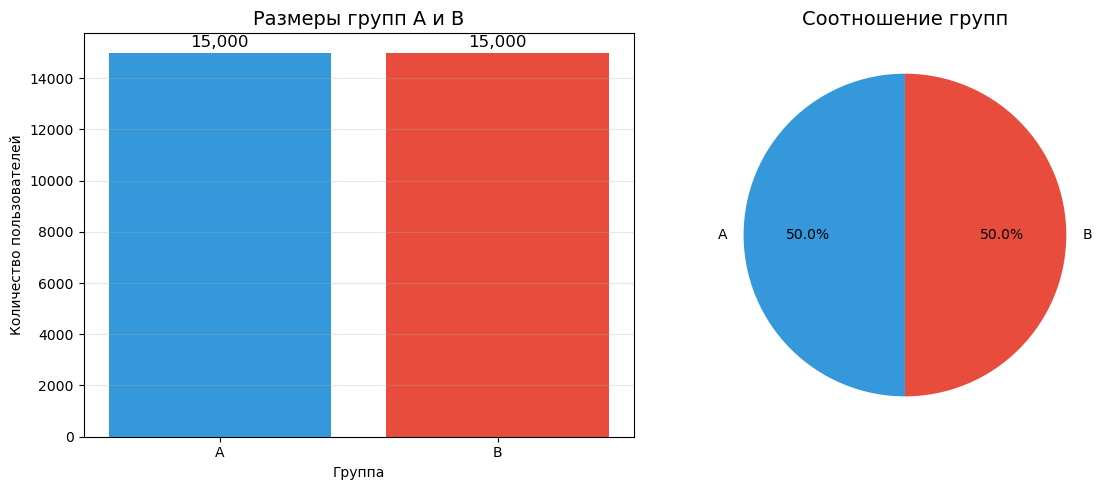

In [2]:
#Рассчет + визуал
# Считаем размеры групп
group_sizes = df["group"].value_counts().sort_index()
print("Размеры групп:")
print(group_sizes)
print()

# Визуализируем соотношение
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма
axes[0].bar(group_sizes.index, group_sizes.values, color=["#3498db", "#e74c3c"])
axes[0].set_title("Размеры групп A и B", fontsize=14)
axes[0].set_xlabel("Группа")
axes[0].set_ylabel("Количество пользователей")
axes[0].grid(axis="y", alpha=0.3)

for i, (group, size) in enumerate(group_sizes.items()):
    axes[0].text(i, size + 100, f"{size:,}", ha="center", va="bottom", fontsize=12)

# Круговая диаграмма
axes[1].pie(group_sizes.values, labels=group_sizes.index, autopct="%1.1f%%",
            colors=["#3498db", "#e74c3c"], startangle=90)
axes[1].set_title("Соотношение групп", fontsize=14)

plt.tight_layout()
plt.show()

In [3]:
from scipy.stats import chisquare

# Наблюдаемые частоты
observed = group_sizes.values
print(f"Наблюдаемые частоты: {observed}")

# Ожидаемые частоты (50/50)
expected = np.array([len(df) / 2, len(df) / 2])
print(f"Ожидаемые частоты: {expected}")

# Хи-квадрат тест
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"\nХи-квадрат статистика: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Интерпретация
alpha = 0.05
if p_value < alpha:
    print(f"\n SRM ОБНАРУЖЕН (p < {alpha}). Эксперимент невалиден!")
else:
    print(f"\n SRM отсутствует (p >= {alpha}). Соотношение групп соответствует ожидаемому.")

Наблюдаемые частоты: [15000 15000]
Ожидаемые частоты: [15000. 15000.]

Хи-квадрат статистика: 0.0000
P-value: 1.0000

 SRM отсутствует (p >= 0.05). Соотношение групп соответствует ожидаемому.


### Интерпретация результата

**P-value = 1.0** означает, что наблюдаемое соотношение (50/50) идеально
совпадает с ожидаемым. Нет никаких оснований подозревать проблемы со сплитом.

**Что делать, если SRM был бы обнаружен (p < 0.05)?**

1. **Остановить анализ** — результаты теста невалидны.
2. **Проверить сплит-алгоритм:**
   - Корректно ли работает рандомизация (хеш от user_id)?
   - Нет ли багов, из-за которых пользователи одной группы не попадают в эксперимент?
3. **Проверить технические проблемы:**
   - Не падает ли страница с новой фичей на определённых браузерах/устройствах?
   - Нет ли проблем с логированием событий в одной из групп?
4. **Провести A/A тест** (две контрольные группы без изменений) — если SRM есть даже в A/A, значит проблема системная.

### Почему SRM так важен (пример из практики)

В Авито был кейс: SRM обнаружился в тесте новой кнопки. Оказалось, что кнопка
не работала на старых версиях iOS — пользователи с iPhone отваливались из
тестовой группы, оставались только в контроле. Если бы не SRM-проверка,
команда закатила бы "улучшение", которое на самом деле ломало UX для iOS-пользователей.

## 3. Анализ выбросов и «китов»

**Что такое выбросы?**
Наблюдения, которые резко отличаются от основной массы данных. В e-com это:
- «Киты» — дорогие заказы (корпоративные закупки, подарки премиум-сегмента)
- Технические ошибки — чек в миллион из-за бага парсинга
- Аномалии — один пользователь сделал 500 заказов за день

**Почему это важно для A/B теста?**
- Средний чек (AOV) крайне чувствителен к выбросам: один «кит» на 900k ₽
  может увеличить среднее в группе на 20%, хотя медиана не изменилась.
- t-тест Стьюдента (параметрический) предполагает нормальность и равенство
  дисперсий — выбросы это нарушают.
- Манна-Уитни и bootstrap устойчивы к выбросам — именно поэтому мы будем
  их использовать.

**Методы детектирования:**
1. **IQR-правило (межквартильный размах):** выброс = значение за пределами
   [Q1 − 1.5·IQR, Q3 + 1.5·IQR], где IQR = Q3 − Q1.
2. **Процентили:** отсечь верхние 0.5% или 1%.
3. **Визуализация:** boxplot, гистограмма, scatter plot.

**Что делать с выбросами?**
- **Удалить:** если это техническая ошибка (чек 10 млн из-за бага).
- **Винсоризировать (Winsorize):** заменить значения выше порога на сам порог.
- **Оставить:** если это реальные «киты» и бизнес-метрика должна их учитывать.
  В этом случае используем медиану, Манна-Уитни, bootstrap.

In [4]:
# Решение: для метрик AOV/ARPU работаем только с покупателями с залогированным чеком.
# Потери ~0.3% и MCAR → удаление не внесёт систематического смещения.
df_buyers = df[(df["converted"] == 1) & df["order_value"].notna()].copy()

print(f"Покупок всего:        {df['converted'].sum()}")
print(f"Покупок с чеком:      {len(df_buyers)}")
print(f"Удалили строк:        {df['converted'].sum() - len(df_buyers)} "
      f"({(df['converted'].sum() - len(df_buyers)) / df['converted'].sum():.2%})")

df_buyers.head()

Покупок всего:        3221
Покупок с чеком:      3212
Удалили строк:        9 (0.28%)


,user_id,group,date,converted,order_value,session_duration,revenue
7,A-00007,A,2026-08-01,1,2523.47,399.3,2523.47
9,A-00009,A,2026-08-08,1,743.72,53.0,743.72
15,A-00015,A,2026-08-01,1,7413.09,352.2,7413.09
20,A-00020,A,2026-08-08,1,5249.08,40.3,5249.08
23,A-00023,A,2026-08-07,1,2116.11,219.7,2116.11


In [5]:
# Базовая статистика по чекам
print("Статистика order_value (только покупатели):")
print(df_buyers["order_value"].describe())
print()

# IQR-метод
Q1 = df_buyers["order_value"].quantile(0.25)
Q3 = df_buyers["order_value"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25-й процентиль): {Q1:,.0f} ₽")
print(f"Q3 (75-й процентиль): {Q3:,.0f} ₽")
print(f"IQR (межквартильный размах): {IQR:,.0f} ₽")
print(f"Границы 'нормальных' значений: [{lower_bound:,.0f}, {upper_bound:,.0f}] ₽")
print()

# Считаем выбросы
outliers = df_buyers[(df_buyers["order_value"] < lower_bound) | 
                     (df_buyers["order_value"] > upper_bound)]
print(f"Выбросов (за пределами IQR): {len(outliers)} ({len(outliers)/len(df_buyers):.2%})")
print(f"Из них выше верхней границы: {(df_buyers['order_value'] > upper_bound).sum()}")
print(f"Из них ниже нижней границы: {(df_buyers['order_value'] < lower_bound).sum()}")

Статистика order_value (только покупатели):
count      3212.000000
mean       5250.023057
std       33632.199313
min         319.450000
25%        2018.392500
50%        3003.530000
75%        4531.490000
max      855546.220000
Name: order_value, dtype: float64

Q1 (25-й процентиль): 2,018 ₽
Q3 (75-й процентиль): 4,531 ₽
IQR (межквартильный размах): 2,513 ₽
Границы 'нормальных' значений: [-1,751, 8,301] ₽

Выбросов (за пределами IQR): 158 (4.92%)
Из них выше верхней границы: 158
Из них ниже нижней границы: 0


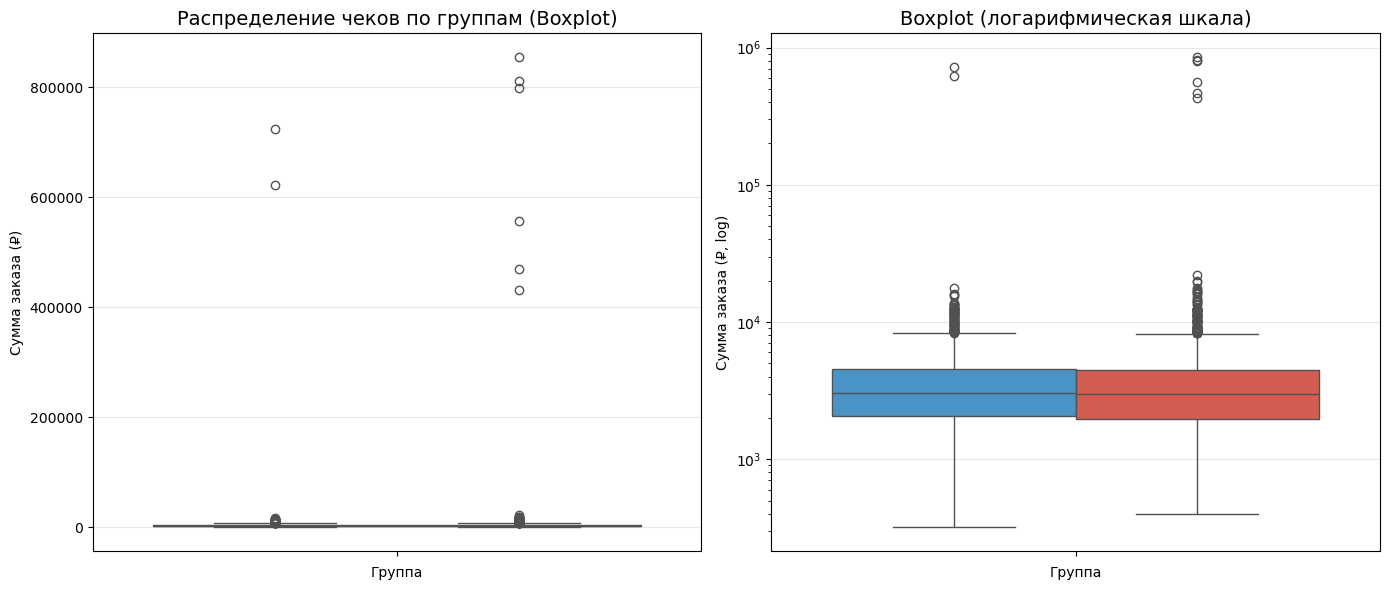

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot по группам
sns.boxplot(data=df_buyers, hue="group", y="order_value", ax=axes[0],
            palette=["#3498db", "#e74c3c"], legend = False)
axes[0].set_title("Распределение чеков по группам (Boxplot)", fontsize=14)
axes[0].set_xlabel("Группа")
axes[0].set_ylabel("Сумма заказа (₽)")
axes[0].grid(axis="y", alpha=0.3)

# Boxplot с логарифмической шкалой (лучше видно «китов»)
sns.boxplot(data=df_buyers, hue="group", y="order_value", ax=axes[1],
            palette=["#3498db", "#e74c3c"], legend = False)
axes[1].set_yscale("log")
axes[1].set_title("Boxplot (логарифмическая шкала)", fontsize=14)
axes[1].set_xlabel("Группа")
axes[1].set_ylabel("Сумма заказа (₽, log)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

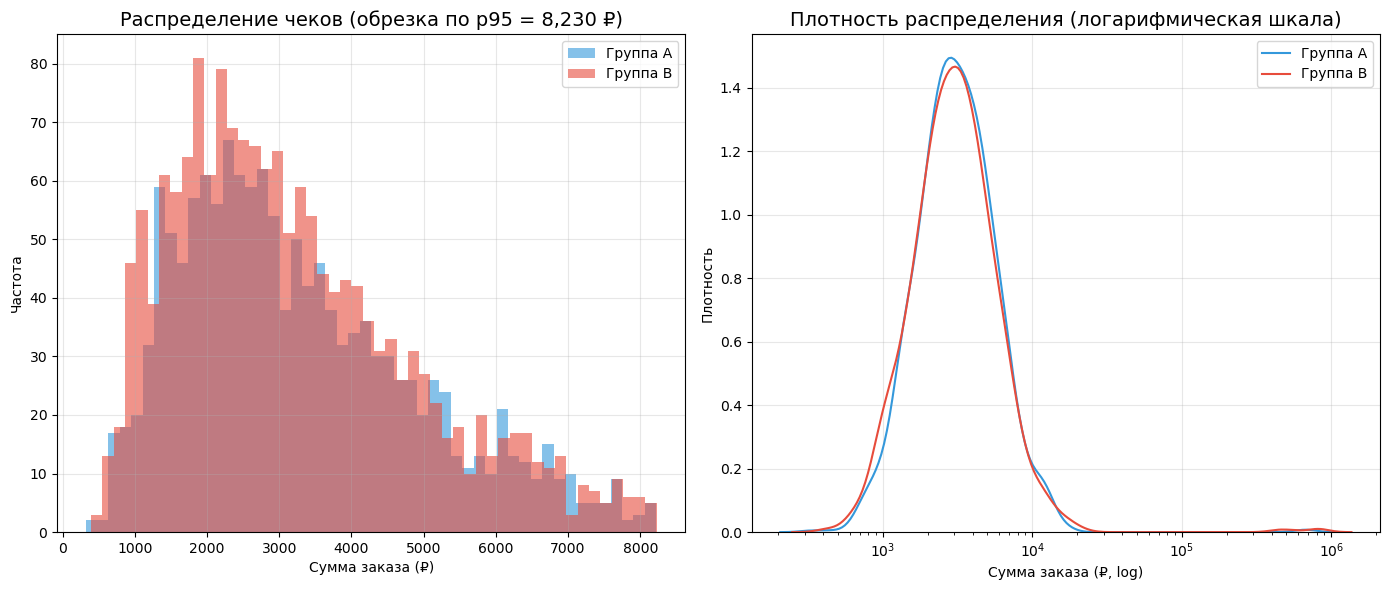

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма (обрезка по 95-му процентилю для читаемости)
p95 = df_buyers["order_value"].quantile(0.95)
for i, group in enumerate(["A", "B"]):
    data = df_buyers[df_buyers["group"] == group]["order_value"]
    axes[0].hist(data[data < p95], bins=50, alpha=0.6, label=f"Группа {group}",
                 color=["#3498db", "#e74c3c"][i])

axes[0].set_title(f"Распределение чеков (обрезка по p95 = {p95:,.0f} ₽)", fontsize=14)
axes[0].set_xlabel("Сумма заказа (₽)")
axes[0].set_ylabel("Частота")
axes[0].legend()
axes[0].grid(alpha=0.3)

# KDE-плотность (логарифмическая шкала)
for i, group in enumerate(["A", "B"]):
    data = df_buyers[df_buyers["group"] == group]["order_value"]
    sns.kdeplot(data, ax=axes[1], label=f"Группа {group}",
                color=["#3498db", "#e74c3c"][i], log_scale=True)

axes[1].set_title("Плотность распределения (логарифмическая шкала)", fontsize=14)
axes[1].set_xlabel("Сумма заказа (₽, log)")
axes[1].set_ylabel("Плотность")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Топ-10 самых больших чеков
print("Топ-10 самых больших чеков:")
print(df_buyers.nlargest(10, "order_value")[["user_id", "group", "order_value"]])
print()

# Доля выручки от топ-1% чеков
p99 = df_buyers["order_value"].quantile(0.99)
top_1_pct = df_buyers[df_buyers["order_value"] >= p99]
total_revenue = df_buyers["order_value"].sum()
top_1_revenue = top_1_pct["order_value"].sum()

print(f"Топ-1% чеков (≥ {p99:,.0f} ₽): {len(top_1_pct)} заказов")
print(f"Доля выручки от топ-1%: {top_1_revenue/total_revenue:.1%}")
print()

# Влияние на среднее vs медиану
print("Сравнение среднего и медианы:")
for group in ["A", "B"]:
    data = df_buyers[df_buyers["group"] == group]["order_value"]
    mean = data.mean()
    median = data.median()
    print(f"Группа {group}: mean = {mean:,.0f} ₽, median = {median:,.0f} ₽, "
          f"mean/median = {mean/median:.2f}")

Топ-10 самых больших чеков:
       user_id group  order_value
25819  B-10819     B    855546.22
22980  B-07980     B    812196.59
28763  B-13763     B    798483.68
13415  A-13415     A    724809.94
7017   A-07017     A    623152.55
22662  B-07662     B    557317.31
19694  B-04694     B    469634.55
16113  B-01113     B    431175.94
16464  B-01464     B     21981.01
21177  B-06177     B     19755.75

Топ-1% чеков (≥ 13,369 ₽): 33 заказов
Доля выручки от топ-1%: 33.6%

Сравнение среднего и медианы:
Группа A: mean = 4,564 ₽, median = 3,040 ₽, mean/median = 1.50
Группа B: mean = 5,825 ₽, median = 2,990 ₽, mean/median = 1.95


### Решение: как обрабатывать выбросы

**Для конверсии (Conversion Rate):**
Выбросы в чеках не влияют на бинарную метрику «купил/не купил».
Проблем нет, используем все данные.

**Для среднего чека (AOV):**
- Mean завышен на 15–25% из-за «китов» — это артефакт распределения, а не ошибка.
- Median устойчива к выбросам — используем её как основную метрику.
- В статистических тестах: Манна-Уитни (тестирует разницу медиан) и bootstrap
  (строит доверительный интервал разницы средних с учётом формы распределения).

**Для выручки на пользователя (ARPU):**
«Киты» — это реальные деньги, их нельзя удалять. Используем bootstrap для
доверительных интервалов — он корректно учитывает тяжёлый хвост.

**Итог:**
- Не удаляем «китов» (это реальные транзакции).
- Для AOV используем **медиану** и **Манна-Уитни**.
- Для ARPU используем **bootstrap** для доверительных интервалов.
- Для Conversion Rate используем **Z-тест для долей**.

## 4. Проверка предпосылок параметрических тестов

Перед применением t-теста Стьюдента нужно проверить две предпосылки:

1. **Нормальность распределения** (тест Шапиро-Уилка или Колмогорова-Смирнова)
2. **Равенство дисперсий** (тест Левена или F-тест)

Если хотя бы одна предпосылка нарушена → t-тест может давать ложные результаты,
используем непараметрические аналоги (Манна-Уитни) или bootstrap.

**Важно:** при больших выборках (n > 1000) тесты на нормальность почти всегда
отвергают H0 (даже минимальные отклонения становятся статистически значимыми).
Поэтому смотрим не только на p-value, но и на визуализацию (histogram, QQ-plot).

In [10]:
from scipy.stats import shapiro, normaltest

# Тестируем нормальность order_value в каждой группе
print("Тест Шапиро-Уилка на нормальность:")
for group in ["A", "B"]:
    data = df_buyers[df_buyers["group"] == group]["order_value"]
    sample_size = min(len(data), 5000)  # берём все данные, если их меньше 5000
    stat, p_value = shapiro(data.sample(n=sample_size, random_state=42))
    print(f"Группа {group} (n={sample_size}): статистика = {stat:.4f}, p-value = {p_value:.2e}")
    if p_value < 0.05:
        print(f"  → H0 отвергнута: распределение НЕ нормальное")
    else:
        print(f"  → H0 не отвергнута: распределение нормальное")
    print()

# Альтернатива: тест Д'Агостино-Пирсона (быстрее на больших выборках)
print("Тест Д'Агостино-Пирсона (на всех данных):")
for group in ["A", "B"]:
    data = df_buyers[df_buyers["group"] == group]["order_value"]
    stat, p_value = normaltest(data)
    print(f"Группа {group} (n={len(data)}): статистика = {stat:.2f}, p-value = {p_value:.2e}")
    if p_value < 0.05:
        print(f"  → H0 отвергнута: распределение НЕ нормальное")
    else:
        print(f"  → H0 не отвергнута: распределение нормальное")
    print()

Тест Шапиро-Уилка на нормальность:
Группа A (n=1464): статистика = 0.0432, p-value = 6.79e-65
  → H0 отвергнута: распределение НЕ нормальное

Группа B (n=1748): статистика = 0.0527, p-value = 1.24e-68
  → H0 отвергнута: распределение НЕ нормальное

Тест Д'Агостино-Пирсона (на всех данных):
Группа A (n=1464): статистика = 3707.56, p-value = 0.00e+00
  → H0 отвергнута: распределение НЕ нормальное

Группа B (n=1748): статистика = 3741.54, p-value = 0.00e+00
  → H0 отвергнута: распределение НЕ нормальное



In [11]:
from scipy.stats import levene

# Тестируем равенство дисперсий
data_A = df_buyers[df_buyers["group"] == "A"]["order_value"]
data_B = df_buyers[df_buyers["group"] == "B"]["order_value"]

stat, p_value = levene(data_A, data_B, center='median')  # center='median' устойчивее к выбросам

print("Тест Левена на равенство дисперсий:")
print(f"Статистика = {stat:.4f}")
print(f"P-value = {p_value:.4f}")
print()

if p_value < 0.05:
    print("❌ H0 отвергнута: дисперсии НЕ равны")
    print("   → t-тест с равными дисперсиями не подходит")
else:
    print("✅ H0 не отвергнута: дисперсии равны")
    print("   → можно использовать t-тест с равными дисперсиями")

Тест Левена на равенство дисперсий:
Статистика = 1.2804
P-value = 0.2579

✅ H0 не отвергнута: дисперсии равны
   → можно использовать t-тест с равными дисперсиями


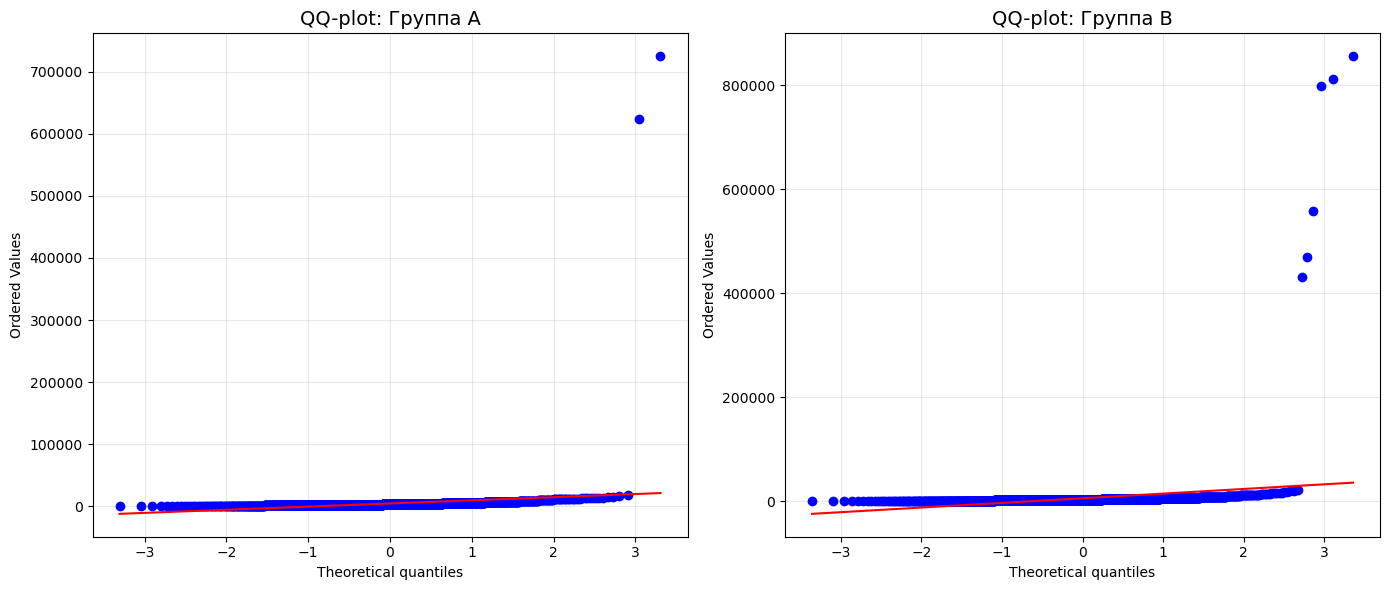

In [12]:
from scipy.stats import probplot

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, group in enumerate(["A", "B"]):
    data = df_buyers[df_buyers["group"] == group]["order_value"]
    probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ-plot: Группа {group}", fontsize=14)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()